In [2]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso, Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Set the device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print('device:', device)

device: mps


In [3]:
data = pd.read_csv('ready.csv').drop(columns = 'Unnamed: 0')
data_for_backtest = data[data['year_month']>='2018']
data_for_model = data[data['year_month']<'2018']

**用於回測的資料2018~2022，不放入訓練中，2018之前的資料以7:3的方式分為Train/Valid**

In [5]:
def model_result(data_for_model, which_model, all_variables=True, **kwargs):
    
    # Step 1: Randomly split the data into 70% Training and 30% Validation set
    train_data, valid_data = train_test_split(data_for_model, test_size=0.3, random_state=42)

    if all_variables:
        Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                     'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']
    elif not all_variables:
        Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']

    # Step 2: Build a regression model based on the training set
    X_train = train_data[Variables]
    y_train = train_data['month_exret']

    # Creating and fitting the model
    if which_model == 'LR':
        model = LinearRegression()
        
    elif which_model == 'Lasso':
        model = Lasso(alpha = 1, random_state=42, **kwargs)

    elif which_model == 'Ridge':
        model = Ridge(alpha = 1, random_state=42, **kwargs)

    elif which_model == 'DT':
        model = DecisionTreeRegressor(random_state=42,
                                      splitter = 'best', 
                                      max_depth = 6, 
                                      min_samples_leaf = 60, 
                                      min_weight_fraction_leaf = 0.03,
                                      max_features = 'sqrt',
                                      max_leaf_nodes = 20, **kwargs)
                                        

    elif which_model == 'RF':
        model = RandomForestRegressor(random_state=42,
                                      max_depth = 6, 
                                      min_samples_leaf = 60, 
                                      min_weight_fraction_leaf = 0.03,
                                      max_features = 'sqrt',
                                      max_leaf_nodes = 20,
                                      n_jobs=-1,
                                      n_estimators=25, **kwargs)
        
    elif which_model == 'XGBoost':
        model = XGBRegressor(random_state=42, 
                             objective='reg:squarederror',
                             n_jobs=-1,
                             learning_rate=0.2, 
                             n_estimators=20, 
                             max_depth=12, 
                             min_child_weight=250,
                             subsample=0.5, 
                             colsample_bytree=0.7, 
                             gamma=0.4,
                             reg_alpha=0, 
                             reg_lambda=2.5, **kwargs)

    elif which_model == 'LightGBM':
        model = LGBMRegressor(random_state=42,
                               n_jobs=-1, 
                               verbose = -1,
                               n_estimators = 20, 
                               max_depth = 6, 
                               min_child_weight = 32, 
                               subsample = 0.5,
                               reg_alpha = 4, 
                               reg_lambda = 3.3, 
                               learning_rate = 0.3, 
                               num_leaves = 8,
                               subsample_for_bin = 4096, **kwargs)
        
    else:
        print('Please Specify a Valid Model: LR/DT/RF/Lasso/Ridge/XGBoost/LightGBM')

    model.fit(X_train, y_train)

    # Evaluating on the training set
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Step 3: Use the regression model on the validation set
    X_valid = valid_data[Variables]
    y_valid = valid_data['month_exret']

    # Evaluating on the validation set
    y_valid_pred = model.predict(X_valid)
    mse_valid = mean_squared_error(y_valid, y_valid_pred)
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    r2_valid = r2_score(y_valid, y_valid_pred)

    # Step 4: Report the MSE, MAE, and R-squared on the training and validation set
    results = pd.DataFrame({
        'Metric': ['MSE', 'MAE', 'R-squared'],
        'Training Set': [mse_train, mae_train, r2_train],
        'Validation Set': [mse_valid, mae_valid, r2_valid]
    })

    # Displaying the results
    return results, model

def get_results():
    models = ['LR', 'Lasso', 'Ridge', 'DT', 'RF', 'LightGBM', 'XGBoost']
    TF = [True, False]
    dfs = []
    for m in models:
        for bl in TF:
            df, _ = model_result(data_for_model, which_model = m, all_variables = bl)
            df['model'] = m
            df['All Variables'] = bl
            
            dfs.append(df)
        
    return pd.concat(dfs)

    df = get_results()

# Model & Variables Comparism
* Linear Models(LR, Lasso, Ridge): Underfit, 且調整參數無效
* Tree Based(DT, XGBoost, LightGBM, RF): Overfit, 須再調整參數

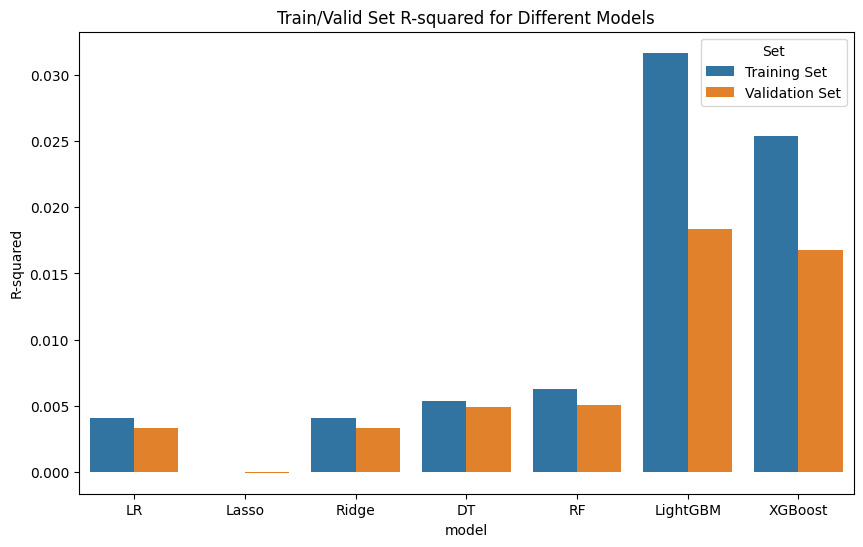

In [36]:
r2_between_models = df[df['All Variables']==True].loc[2]

# 整理數據
df_melt = r2_between_models.melt(id_vars=['model'], value_vars=['Training Set', 'Validation Set'], var_name='Set', value_name='R-squared')

# 繪製條形圖
plt.figure(figsize=(10, 6))
plt.title('Train/Valid Set R-squared for Different Models')
sns.barplot(x='model', y='R-squared', hue='Set', data=df_melt)
plt.show()

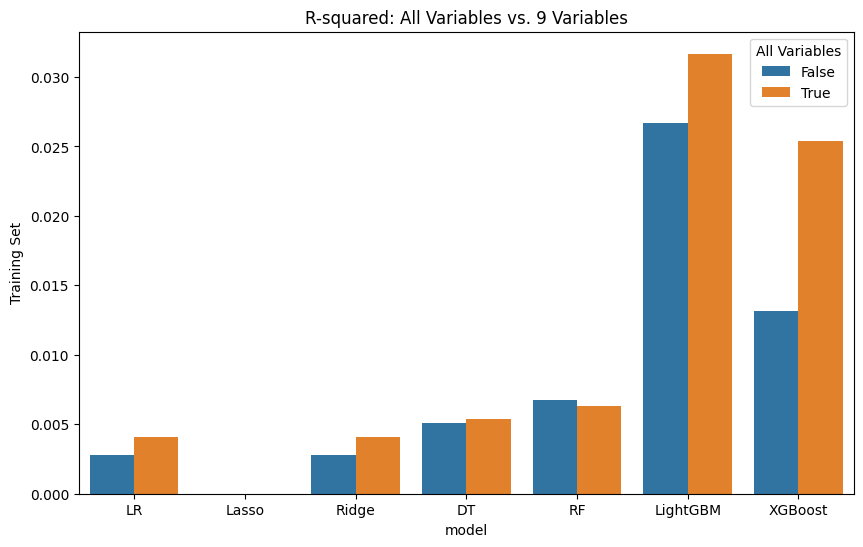

In [37]:
df_train = df[df['Metric'] == 'R-squared']

# 繪製條形圖
plt.figure(figsize=(10, 6))
plt.title('R-squared: All Variables vs. 9 Variables')
sns.barplot(x='model', y='Training Set', hue='All Variables', data=df_train)

plt.show()

# OOS R2

In [34]:
 def get_OOS_R2(all_variables):
    print('All Variables:', all_variables)
    
    models = ['LR', 'Lasso', 'Ridge', 'DT', 'RF', 'LightGBM', 'XGBoost']
    for m in models:
        _, model = model_result(data_for_model, which_model = m, all_variables = all_variables)
        if all_variables:
            Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                         'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                         'mom12m', 'mvel1', 'retvol']
        elif not all_variables:
            Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                        'mom12m', 'mvel1', 'retvol']

        X_oos = data_for_backtest[Variables]
        Y_oos = data_for_backtest['month_exret']

        Y_pred_oos = model.predict(X_oos)
        OOSR2 = 1-((np.array(Y_oos) - Y_pred_oos)**2).sum()/(np.array(Y_oos)**2).sum()
        print(m)
        print(100*(OOSR2))
        print('\n')

get_OOS_R2(True)
get_OOS_R2(False)

All Variables: True
LR
0.060879318129669624


Lasso
0.0035534250575897097


Ridge
0.06120418615679357


DT
-0.03033438143813516


RF
0.1385804270393698


LightGBM
0.10663487666512372


XGBoost
-0.34679811851752174


All Variables: False
LR
0.15178270012454753


Lasso
0.0035534250575897097


Ridge
0.1518674174409873


DT
0.10355194212413599


RF
0.12439320311066204


LightGBM
0.026141351887587483


XGBoost
-0.14303750022293116




# Tuning

## Lasso and Ridge Regression Tuning
**沒有影響，我覺得線性模型不適用於此數據**

100%|██████████| 20/20 [00:05<00:00,  3.68it/s]


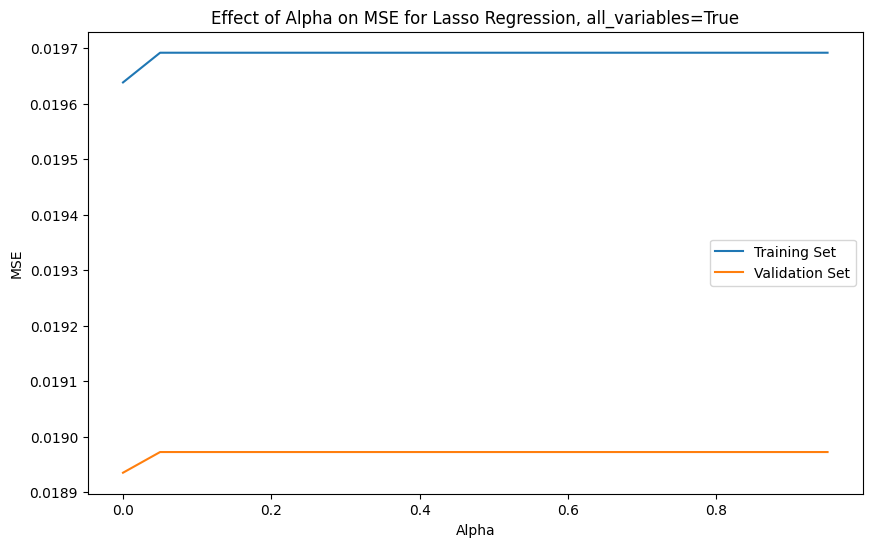

100%|██████████| 20/20 [00:03<00:00,  5.62it/s]


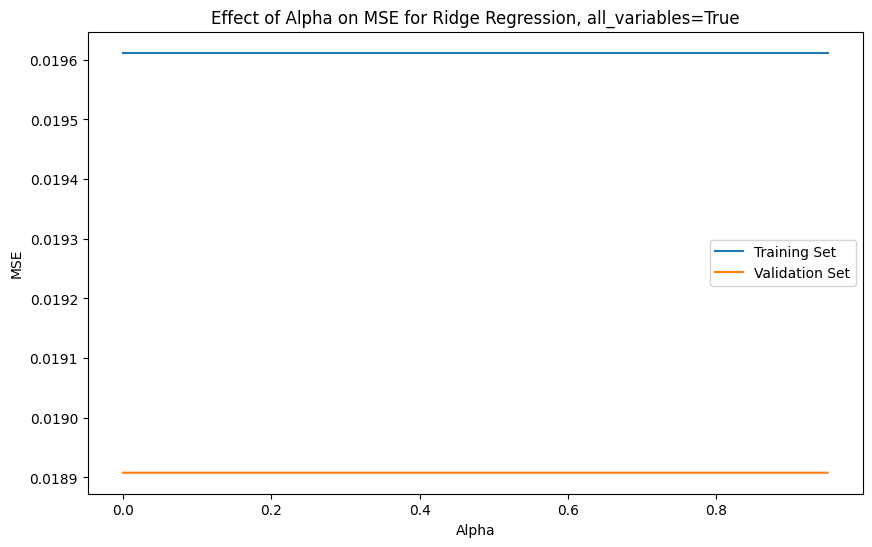

100%|██████████| 20/20 [00:05<00:00,  3.52it/s]


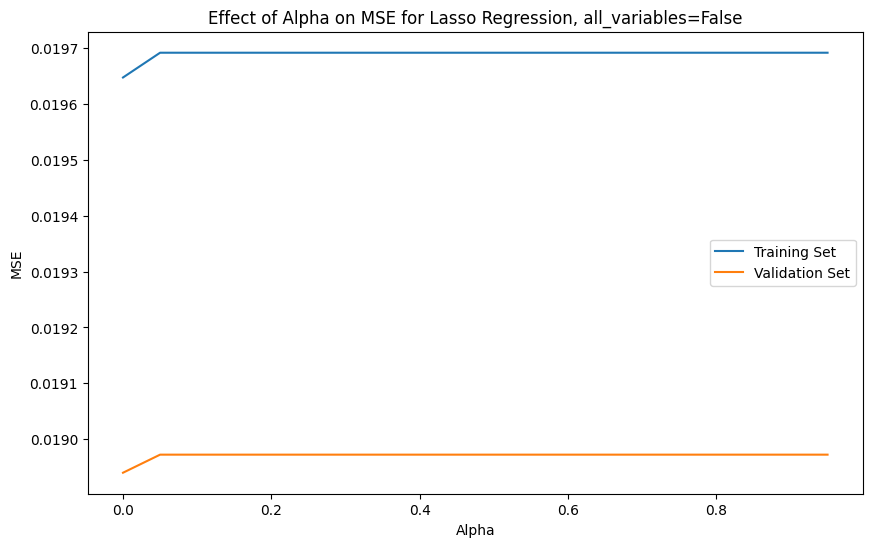

100%|██████████| 20/20 [00:02<00:00,  7.62it/s]


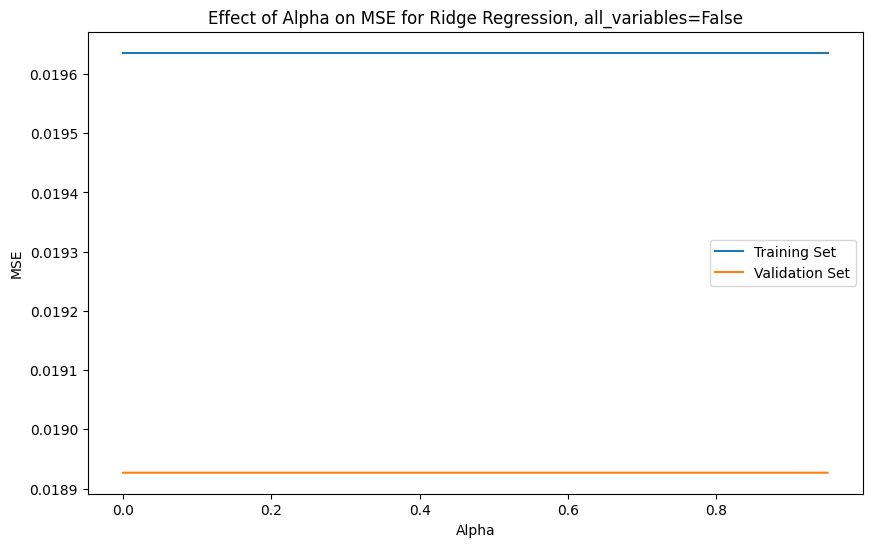

In [15]:
alphas = np.arange(0.0001, 1, 0.05)

## All Variables
# Lasso Regression
# 初始化兩個空列表來存儲訓練集和驗證集的 MSE
mse_train = []
mse_valid = []

# 對每個 alpha 值，訓練一個 Lasso 模型，並計算訓練集和驗證集的 MSE
for alpha in tqdm(alphas):
    result = model_result(data_for_model, 'Lasso', all_variables=True, alpha=alpha)
    mse_train.append(result.iloc[0, 1])
    mse_valid.append(result.iloc[0, 2])

# 繪製兩條線來表示訓練集和驗證集的 MSE
plt.figure(figsize=(10, 6))
plt.plot(alphas, mse_train, label='Training Set')
plt.plot(alphas, mse_valid, label='Validation Set')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Effect of Alpha on MSE for Lasso Regression, all_variables=True')
plt.legend()
plt.show()

# Ridge Regression
# 初始化兩個空列表來存儲訓練集和驗證集的 MSE
mse_train = []
mse_valid = []

# 對每個 alpha 值，訓練一個 Ridge 模型，並計算訓練集和驗證集的 MSE
for alpha in tqdm(alphas):
    result = model_result(data_for_model, 'Ridge', all_variables=True, alpha=alpha)
    mse_train.append(result.iloc[0, 1])
    mse_valid.append(result.iloc[0, 2])

# 繪製兩條線來表示訓練集和驗證集的 MSE
plt.figure(figsize=(10, 6))
plt.plot(alphas, mse_train, label='Training Set')
plt.plot(alphas, mse_valid, label='Validation Set')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Effect of Alpha on MSE for Ridge Regression, all_variables=True')
plt.legend()
plt.show()


## 9 Variables:
# Lasso Regression
# 初始化兩個空列表來存儲訓練集和驗證集的 MSE
mse_train = []
mse_valid = []

# 對每個 alpha 值，訓練一個 Lasso 模型，並計算訓練集和驗證集的 MSE
for alpha in tqdm(alphas):
    result = model_result(data_for_model, 'Lasso', all_variables=False, alpha=alpha)
    mse_train.append(result.iloc[0, 1])
    mse_valid.append(result.iloc[0, 2])

# 繪製兩條線來表示訓練集和驗證集的 MSE
plt.figure(figsize=(10, 6))
plt.plot(alphas, mse_train, label='Training Set')
plt.plot(alphas, mse_valid, label='Validation Set')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Effect of Alpha on MSE for Lasso Regression, all_variables=False')
plt.legend()
plt.show()

# Ridge Regression
# 初始化兩個空列表來存儲訓練集和驗證集的 MSE
mse_train = []
mse_valid = []

# 對每個 alpha 值，訓練一個 Ridge 模型，並計算訓練集和驗證集的 MSE
for alpha in tqdm(alphas):
    result = model_result(data_for_model, 'Ridge', all_variables=False, alpha=alpha)
    mse_train.append(result.iloc[0, 1])
    mse_valid.append(result.iloc[0, 2])

# 繪製兩條線來表示訓練集和驗證集的 MSE
plt.figure(figsize=(10, 6))
plt.plot(alphas, mse_train, label='Training Set')
plt.plot(alphas, mse_valid, label='Validation Set')
plt.xlabel('Alpha')
plt.ylabel('MSE')
plt.title('Effect of Alpha on MSE for Ridge Regression, all_variables=False')
plt.legend()
plt.show()

## XGB Tuning

In [78]:
def XGB_result(data_for_model, all_variables=True, **kwargs):
    
    # Step 1: Randomly split the data into 70% Training and 30% Validation set
    train_data, valid_data = train_test_split(data_for_model, test_size=0.3, random_state=42)

    if all_variables:
        Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                     'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']
    elif not all_variables:
        Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']

    # Step 2: Build a regression model based on the training set
    X_train = train_data[Variables] 
    y_train = train_data['month_exret']

    # Creating and fitting the model
    model = XGBRegressor(random_state=42, objective='reg:squarederror', **kwargs)
    model.fit(X_train, y_train)

    # Evaluating on the training set
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Step 3: Use the regression model on the validation set
    X_valid = valid_data[Variables]
    y_valid = valid_data['month_exret']

    # Evaluating on the validation set
    y_valid_pred = model.predict(X_valid)
    mse_valid = mean_squared_error(y_valid, y_valid_pred)
    mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    r2_valid = r2_score(y_valid, y_valid_pred)

    # Step 4: Report the MSE, MAE, and R-squared on the training and validation set
    results = pd.DataFrame({
        'Metric': ['MSE', 'MAE', 'R-squared'],
        'Training Set': [mse_train, mae_train, r2_train],
        'Validation Set': [mse_valid, mae_valid, r2_valid]
    })

    # Displaying the results
    return results, model

100%|██████████| 63/63 [00:44<00:00,  1.42it/s]


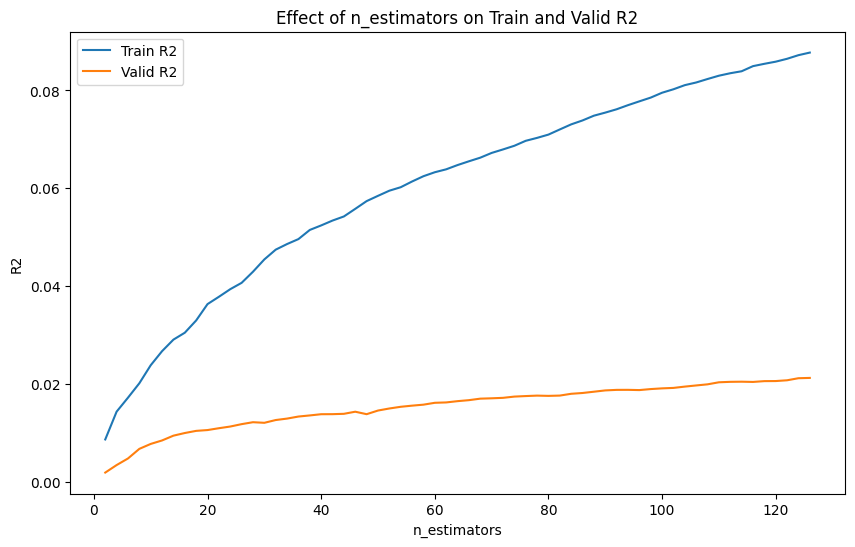

In [106]:
# 1. n_estimators: Number of trees in the forest
n_values = range(2, 128, 2)
train_r2_values = []
valid_r2_values = []

for n in tqdm(n_values):
    res, _ = XGB_result(data_for_model, all_variables=True, n_jobs=-1,
    learning_rate=0.1, n_estimators=n, max_depth=4, min_child_weight=1,
    subsample=0.8, colsample_bytree=0.8, gamma=0, reg_alpha=0, reg_lambda=1)

    train_r2 = res.iloc[2, 1]
    valid_r2 = res.iloc[2, 2]
    train_r2_values.append(train_r2)
    valid_r2_values.append(valid_r2)
 
# Plotting the train_r2 and valid_r2 against n
plt.figure(figsize=(10, 6))
plt.plot(n_values, train_r2_values, label='Train R2')
plt.plot(n_values, valid_r2_values, label='Valid R2')
plt.xlabel('n_estimators')
plt.ylabel('R2')
plt.title('Effect of n_estimators on Train and Valid R2')
plt.legend()
plt.show()


# 經測試後得到：
# n_estimators=20, max_depth=12, min_child_weight=250, gamma = 0.4, subsample=0.5
# colsample_bytree_values=0.7, reg_alpha = 0, reg_lambda = 2.5, learning_rate = 0.2

In [91]:
import xgboost as xgb
_, XGBmodel = XGB_result(data_for_model, all_variables=True, n_jobs=-1,
    learning_rate=0.1, n_estimators=n, max_depth=4, min_child_weight=1,
    subsample=0.8, colsample_bytree=0.8, gamma=0, reg_alpha=0, reg_lambda=1)

# Assuming XGBmodel is already defined
display(pd.DataFrame({'Feature': XGBmodel.feature_names_in_, 'Importance': XGBmodel.feature_importances_}).sort_values('Importance', ascending=False))

,Feature,Importance
1,OTMP_IV_mean,0.222190
2,RVol_mean,0.216569
11,mom1m,0.079104
13,mvel1,0.071044
9,indmom,0.060143
7,dolvol,0.057506
5,PVol_mean,0.041024
3,IVol_mean,0.037579
4,CVol_mean,0.036435
14,retvol,0.033764


## Decision Tree & Random Forest Tuning

In [39]:
def DT_result(data_for_model, all_variables=True, **kwargs):
    
    # Step 1: Randomly split the data into 70% Training and 30% Validation set
    train_data, valid_data = train_test_split(data_for_model, test_size=0.3, random_state=42)

    if all_variables:
        Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                     'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']
    elif not all_variables:
        Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']

    # Step 2: Build a regression model based on the training set
    X_train = train_data[Variables] 
    y_train = train_data['month_exret']

    # Creating and fitting the model
    model = DecisionTreeRegressor(random_state=42, **kwargs)
    model.fit(X_train, y_train)

    # Evaluating on the training set
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    mae_train = mean_absolute_error(y_train, y_train_pred)
    r2_train = r2_score(y_train, y_train_pred)

    # Step 3: Use the regression model on the validation set
    X_valid = valid_data[Variables]
    y_valid = valid_data['month_exret']
    
    train_score = model.score(X_train, y_train)
    valid_score = model.score(X_valid, y_valid)
    
    # # Evaluating on the validation set
    # y_valid_pred = model.predict(X_valid)
    # mse_valid = mean_squared_error(y_valid, y_valid_pred)
    # mae_valid = mean_absolute_error(y_valid, y_valid_pred)
    # r2_valid = r2_score(y_valid, y_valid_pred)

    # Step 4: Report the MSE, MAE, and R-squared on the training and validation set
    # results = pd.DataFrame({
    #     'Metric': ['MSE', 'MAE', 'R-squared'],
    #     'Training Set': [mse_train, mae_train, r2_train],
    #     'Validation Set': [mse_valid, mae_valid, r2_valid]
    # })

    # Displaying the results
    return train_score, valid_score, model

In [40]:
DecisionTreeRegressor().get_params()

{'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'random_state': None,
 'splitter': 'best'}

100%|██████████| 10/10 [00:06<00:00,  1.52it/s]


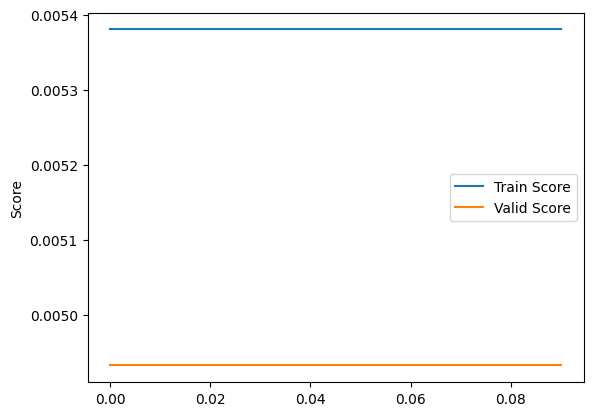

In [41]:
n_values = np.arange(0, 0.1, 0.01)
train_scores = []
valid_scores = []

for n in tqdm(n_values):
    train_score, valid_score, DTmodel = DT_result(data_for_model, 
                                        splitter = 'best', 
                                        max_depth = 6, 
                                        min_samples_leaf = 60, 
                                        min_weight_fraction_leaf = 0.03,
                                        max_features = 'sqrt',
                                        max_leaf_nodes = 20,
                                        min_impurity_decrease = 0)
    
    train_scores.append(train_score)
    valid_scores.append(valid_score)

plt.plot(n_values, train_scores, label='Train Score')
plt.plot(n_values, valid_scores, label='Valid Score')
plt.ylabel('Score')
plt.legend()
plt.show()

In [92]:
display(pd.DataFrame({'Feature': DTmodel.feature_names_in_, 'Importance': DTmodel.feature_importances_}).sort_values('Importance', ascending=False))

,Feature,Importance
13,mvel1,0.624689
7,dolvol,0.107341
10,maxret,0.068186
6,chmom,0.049491
2,RVol_mean,0.044770
12,mom12m,0.029662
3,IVol_mean,0.027461
8,Idiovol,0.026051
9,indmom,0.006489
1,OTMP_IV_mean,0.006458


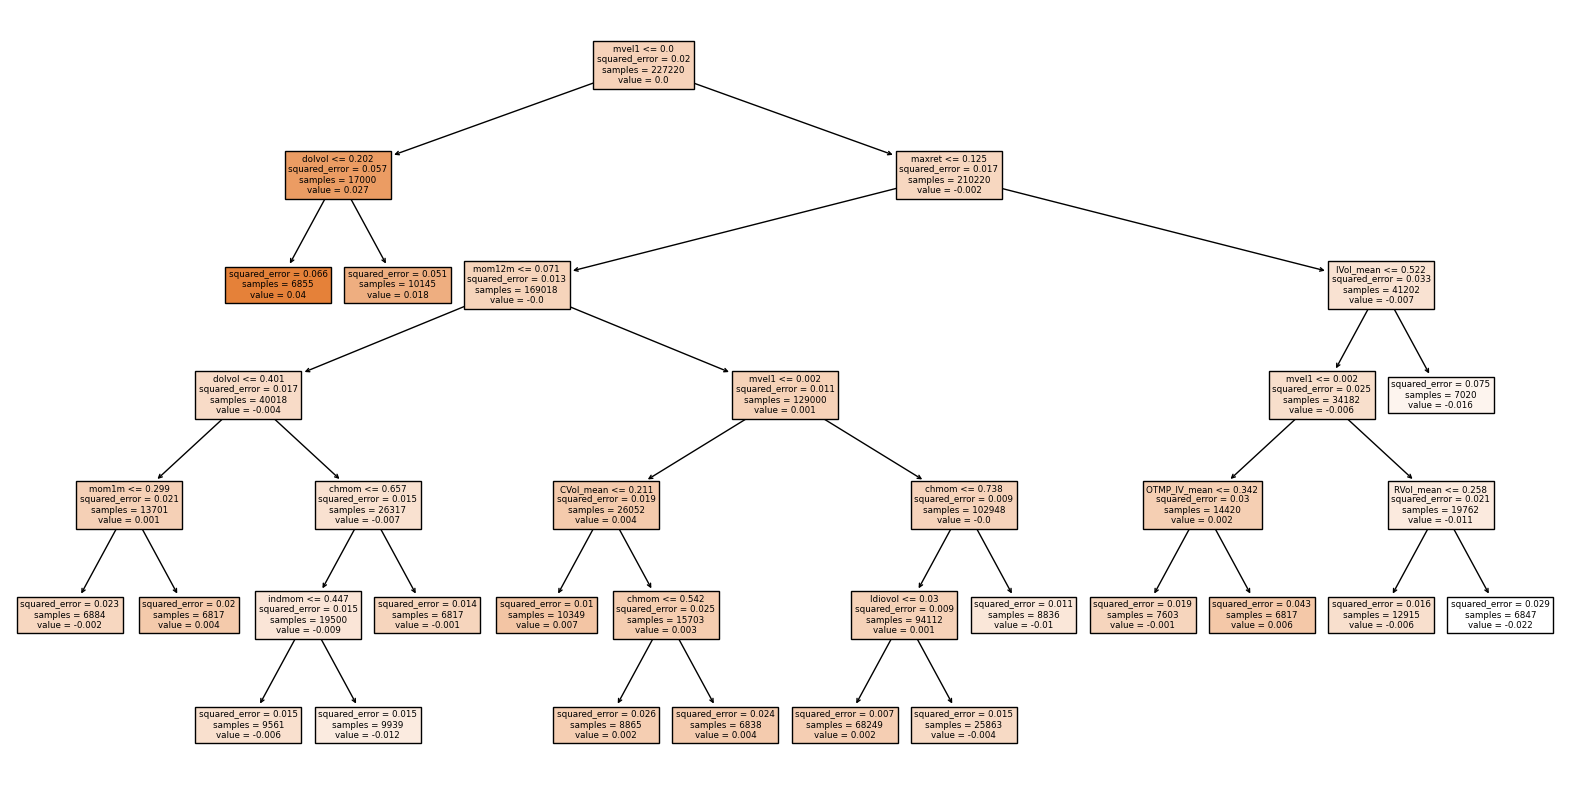

In [56]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(20, 10))
tree.plot_tree(DTmodel, feature_names=DTmodel.feature_names_in_, filled=True)
plt.show()

In [94]:
RandomForestRegressor().get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [58]:
def RF_result(data_for_model, all_variables=True, **kwargs):
    
    # Step 1: Randomly split the data into 70% Training and 30% Validation set
    train_data, valid_data = train_test_split(data_for_model, test_size=0.3, random_state=42)

    if all_variables:
        Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                     'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']
    elif not all_variables:
        Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']

    X_train = train_data[Variables] 
    y_train = train_data['month_exret']

    model = RandomForestRegressor(random_state=42, **kwargs)
    model.fit(X_train, y_train)


    X_valid = valid_data[Variables]
    y_valid = valid_data['month_exret']
    
    train_score = model.score(X_train, y_train)
    valid_score = model.score(X_valid, y_valid)
    
    return train_score, valid_score, model

100%|██████████| 20/20 [00:41<00:00,  2.10s/it]


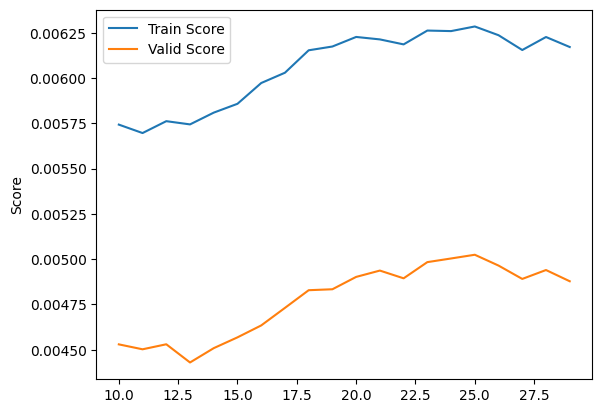

In [60]:
import matplotlib.pyplot as plt

n_values = np.arange(10, 30, 1)
train_scores = []
valid_scores = []

for n in tqdm(n_values):
    train_score, valid_score, RFmodel = RF_result(data_for_model,
                                         max_depth = 6, 
                                         min_samples_leaf = 60, 
                                         min_weight_fraction_leaf = 0.03,
                                         max_features = 'sqrt',
                                         max_leaf_nodes = 20,
                                         n_jobs=-1,
                                         n_estimators=25)
    
    train_scores.append(train_score)
    valid_scores.append(valid_score)

plt.plot(n_values, train_scores, label='Train Score')
plt.plot(n_values, valid_scores, label='Valid Score')
plt.ylabel('Score')
plt.legend()
plt.show()

,Feature,Importance
13,mvel1,0.377277
7,dolvol,0.177677
2,RVol_mean,0.072279
0,ATMC_IV_mean,0.051831
9,indmom,0.051089
8,Idiovol,0.043225
12,mom12m,0.034796
10,maxret,0.030646
1,OTMP_IV_mean,0.028891
6,chmom,0.026892


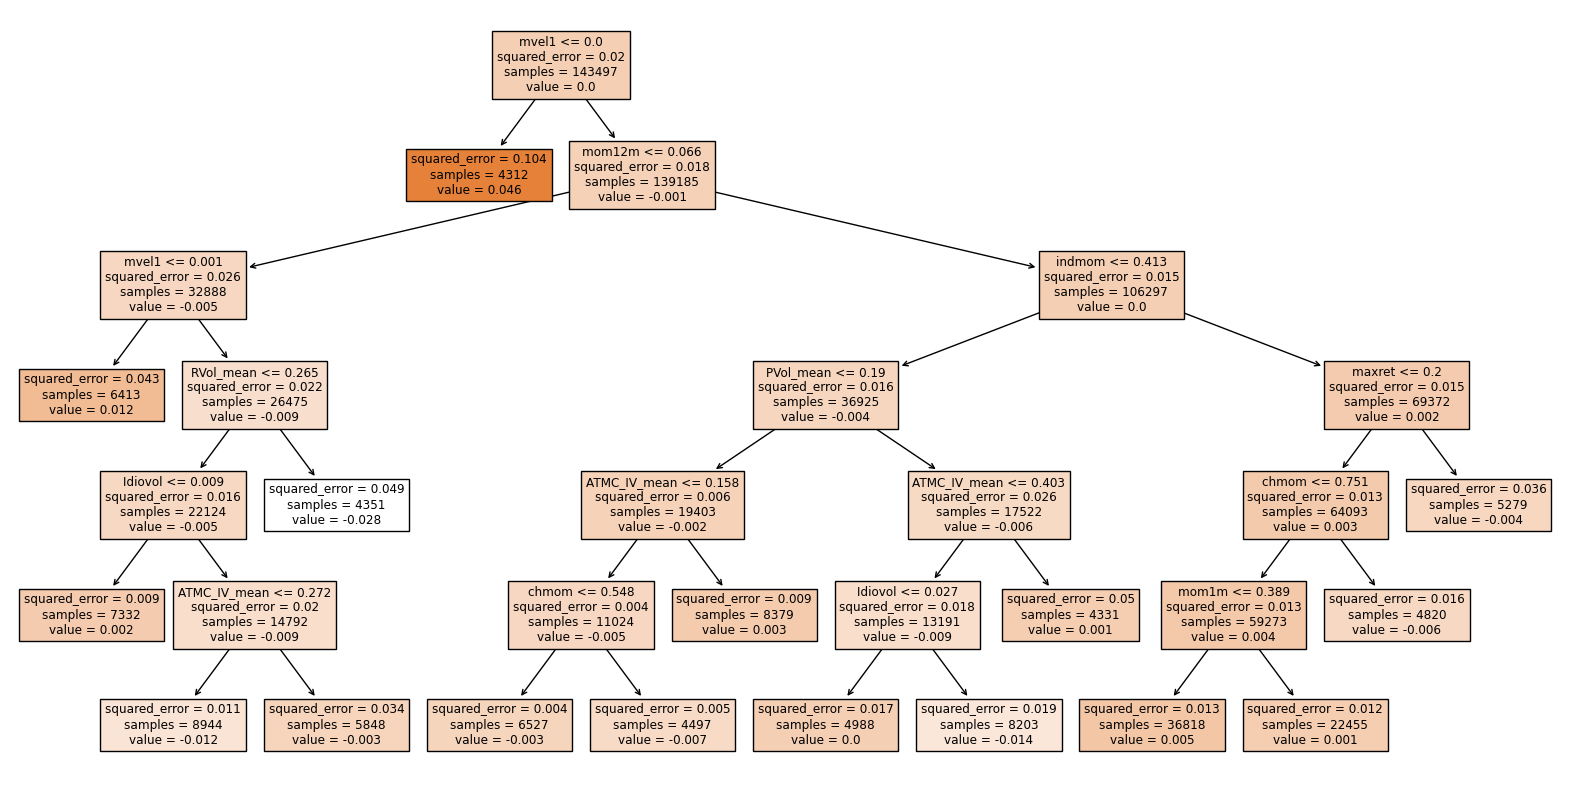

In [94]:
from sklearn import tree
# train_score, valid_score, RFmodel = RF_result(data_for_model,
#                                          max_depth = 6, 
#                                          min_samples_leaf = 60, 
#                                          min_weight_fraction_leaf = 0.03,
#                                          max_features = 'sqrt',
#                                          max_leaf_nodes = 20,
#                                          n_jobs=-1,
#                                          n_estimators=25)
display(pd.DataFrame({'Feature': RFmodel.feature_names_in_, 'Importance': RFmodel.feature_importances_}).sort_values('Importance', ascending=False))
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 10))
tree.plot_tree(RFmodel.estimators_[0], feature_names=RFmodel.feature_names_in_, filled=True)
plt.show()

## LightGBM Regressor Tuning

In [108]:
LGBMRegressor().get_params()

{'boosting_type': 'gbdt',
 'class_weight': None,
 'colsample_bytree': 1.0,
 'importance_type': 'split',
 'learning_rate': 0.1,
 'max_depth': -1,
 'min_child_samples': 20,
 'min_child_weight': 0.001,
 'min_split_gain': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'num_leaves': 31,
 'objective': None,
 'random_state': None,
 'reg_alpha': 0.0,
 'reg_lambda': 0.0,
 'subsample': 1.0,
 'subsample_for_bin': 200000,
 'subsample_freq': 0}

In [6]:
def GBM_result(data_for_model, all_variables=True, **kwargs):
    
    # Step 1: Randomly split the data into 70% Training and 30% Validation set
    train_data, valid_data = train_test_split(data_for_model, test_size=0.3, random_state=42)

    if all_variables:
        Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                     'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']
    elif not all_variables:
        Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']

    # Step 2: Build a regression model based on the training set
    X_train = train_data[Variables] 
    y_train = train_data['month_exret']

    # Creating and fitting the model
    model = LGBMRegressor(random_state=42, **kwargs)
    model.fit(X_train, y_train)

    # Step 3: Use the regression model on the validation set
    X_valid = valid_data[Variables]
    y_valid = valid_data['month_exret']
    
    train_score = model.score(X_train, y_train)
    valid_score = model.score(X_valid, y_valid)

    return train_score, valid_score, model

In [7]:
def GBM_result(data_for_model, all_variables=True, **kwargs):
    
    # Step 1: Randomly split the data into 70% Training and 30% Validation set
    train_data, valid_data = train_test_split(data_for_model, test_size=0.3, random_state=42)

    if all_variables:
        Variables = ['ATMC_IV_mean', 'OTMP_IV_mean', 'RVol_mean', 'IVol_mean', 'CVol_mean',
                     'PVol_mean', 'chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']
    elif not all_variables:
        Variables = ['chmom', 'dolvol', 'Idiovol', 'indmom', 'maxret', 'mom1m',
                     'mom12m', 'mvel1', 'retvol']

    # Step 2: Build a regression model based on the training set
    X_train = train_data[Variables] 
    y_train = train_data['month_exret']

    # Creating and fitting the model
    model = LGBMRegressor(random_state=42, **kwargs)
    model.fit(X_train, y_train)

    # Step 3: Use the regression model on the validation set
    X_valid = valid_data[Variables]
    y_valid = valid_data['month_exret']
    
    train_score = model.score(X_train, y_train)
    valid_score = model.score(X_valid, y_valid)

    return train_score, valid_score, model

100%|██████████| 30/30 [00:05<00:00,  5.57it/s]


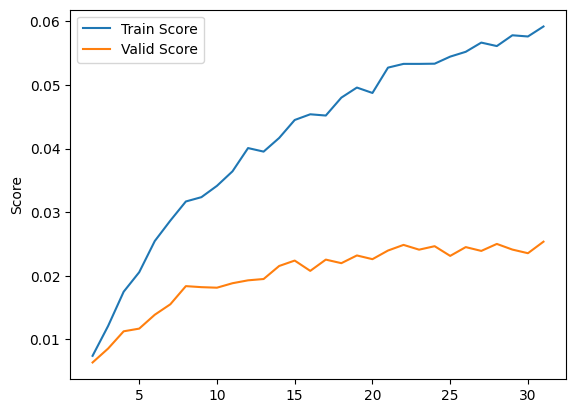

In [60]:
n_values = np.arange(2, 32)

train_scores = []
valid_scores = []

for n in tqdm(n_values):
    train_score, valid_score = GBM_result(data_for_model, 
                                        all_variables=True,
                                        n_jobs=-1, 
                                        verbose = -1,
                                        n_estimators = 20, 
                                        max_depth = 6, 
                                        min_child_weight = 32, 
                                        subsample = 0.5,
                                        reg_alpha = 4, 
                                        reg_lambda = 3.3, 
                                        learning_rate = 0.3, 
                                        num_leaves = 8,
                                        subsample_for_bin = 4096)
                                        
    train_scores.append(train_score)
    valid_scores.append(valid_score)

plt.plot(n_values, train_scores, label='Train Score')
plt.plot(n_values, valid_scores, label='Valid Score')
plt.ylabel('Score')
plt.legend()
plt.show()

In [8]:
_, _, LGBMmodel = GBM_result(data_for_model, 
                        all_variables=True,
                        n_jobs=-1, 
                        verbose = -1,
                        n_estimators = 20, 
                        max_depth = 6, 
                        min_child_weight = 32, 
                        subsample = 0.5,
                        reg_alpha = 4, 
                        reg_lambda = 3.3, 
                        learning_rate = 0.3, 
                        num_leaves = 8,
                        subsample_for_bin = 4096)

In [9]:
display(pd.DataFrame({'Feature': LGBMmodel.feature_name_, 'Importance': LGBMmodel.feature_importances_}).sort_values('Importance', ascending=False))    

,Feature,Importance
9,indmom,23
2,RVol_mean,14
8,Idiovol,14
11,mom1m,14
12,mom12m,14
13,mvel1,14
6,chmom,13
7,dolvol,9
0,ATMC_IV_mean,6
5,PVol_mean,6
